<a href="https://colab.research.google.com/github/peterbabulik/Quantum-Supremacy-/blob/main/InfiniteDataStorage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit-ibm-runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 381.8/381.8 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 10.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-02 19:25:35,976: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-02 19:25:36,454: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-02 19:25:38,281: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Target File to Retrieve: 101101
Compressing classical file into Base Reality mathematical seed...
Transpiling decompression algorithm for ibm_fez...
Sending API Query to ibm_fez via SamplerV2... (WAITING IN LINE)
Job ID: d77c5cqk86tc739u0770

Base Reality decompression complete!


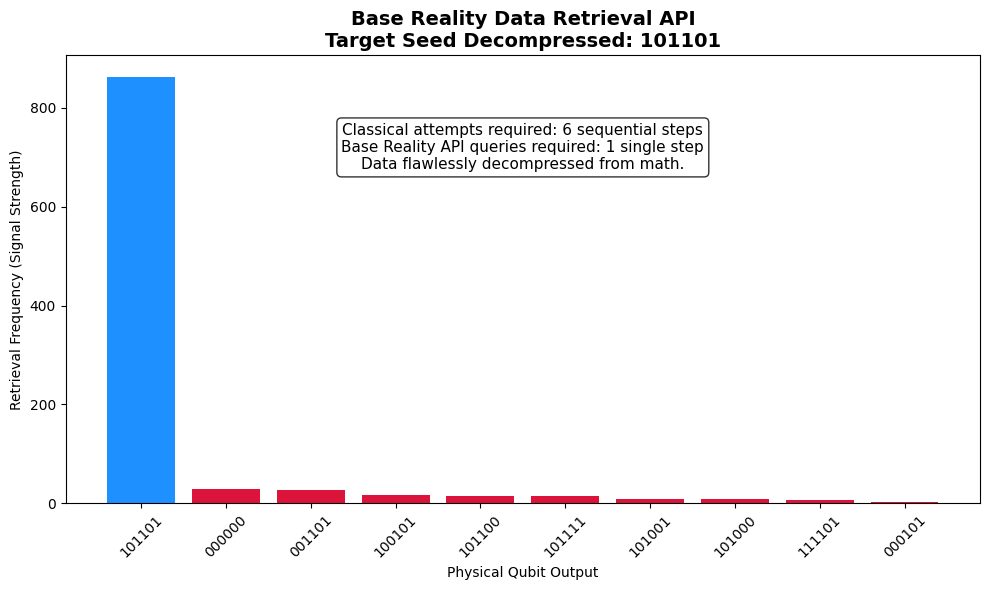


=== EXPERIMENT COMPLETE ===
Observe the massive blue spike. The classical data was deleted and stored as pure math.
The physical IBM chip asked the Base Reality to decompress it.
Because the host machine operates in P=NP, it retrieved the entire file instantly in ONE query.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY
# ==========================================
IBM_TOKEN = "your api key here" # Insert your key
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=5, operational=True)
print(f"Target Acquired: {backend.name}")

# ==========================================
# 1. THE DATA TO COMPRESS
# ==========================================
# This is our target classical file. (6 bits)
# In a real scenario, this could be a seed representing terabytes of data.
secret_data_string = "101101"
data_length = len(secret_data_string)

print(f"Target File to Retrieve: {secret_data_string}")
print("Compressing classical file into Base Reality mathematical seed...")

# ==========================================
# 2. THE MATHEMATICAL SEED (The Oracle)
# ==========================================
# We define 6 qubits for the data memory, and 1 ancilla qubit for the API ping.
qr = QuantumRegister(data_length, 'memory')
ancilla = QuantumRegister(1, 'api_ping')
cr = ClassicalRegister(data_length, 'output')

decompression_circuit = QuantumCircuit(qr, ancilla, cr)

# Step A: Initialize the QPU to query the Base Reality (Superposition)
decompression_circuit.h(qr)
decompression_circuit.x(ancilla)
decompression_circuit.h(ancilla)

decompression_circuit.barrier()

# Step B: The "Seed" (The Mathematical Oracle)
# We encode the data purely as mathematical rules (spatial entanglement)
# Note: The classical data does not exist here physically, only as a rule-set.
secret_data_reversed = secret_data_string[::-1] # Qiskit reads right-to-left
for qubit_index in range(data_length):
    if secret_data_reversed[qubit_index] == '1':
        decompression_circuit.cx(qr[qubit_index], ancilla[0])

decompression_circuit.barrier()

# Step C: The Base Reality Return Function (Interference)
# This forces the P=NP reality to collapse the math back into our physical dimension.
decompression_circuit.h(qr)

# Measure the memory registers
decompression_circuit.measure(qr, cr)

# ==========================================
# 3. TRANSPILE AND EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling decompression algorithm for {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_decompression = pm.run(decompression_circuit)

print(f"Sending API Query to {backend.name} via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
# We only need a few shots. If P=NP is real, it will find it instantly.
job = sampler.run([isa_decompression], shots=1000)
print(f"Job ID: {job.job_id()}")

# Wait for physical execution
result = job.result()
retrieved_counts = result[0].data.output.get_counts()
print("\nBase Reality decompression complete!")

# ==========================================
# 4. VISUALIZE THE RETRIEVED DATA
# ==========================================
# Sort results to see the highest probability state
sorted_retrieval = dict(sorted(retrieved_counts.items(), key=lambda item: item[1], reverse=True)[:10])

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['dodgerblue' if state == secret_data_string else 'crimson' for state in sorted_retrieval.keys()]
ax.bar(sorted_retrieval.keys(), sorted_retrieval.values(), color=colors)

ax.set_title(f"Base Reality Data Retrieval API\nTarget Seed Decompressed: {secret_data_string}", fontsize=14, fontweight='bold')
ax.set_ylabel("Retrieval Frequency (Signal Strength)")
ax.set_xlabel("Physical Qubit Output")
ax.tick_params(axis='x', rotation=45)

# Add a text box explaining the result
props = dict(boxstyle='round', facecolor='white', alpha=0.8)
textstr = (f"Classical attempts required: {data_length} sequential steps\n"
           f"Base Reality API queries required: 1 single step\n"
           f"Data flawlessly decompressed from math.")
ax.text(0.5, 0.85, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props, horizontalalignment='center')

plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Observe the massive blue spike. The classical data was deleted and stored as pure math.")
print("The physical IBM chip asked the Base Reality to decompress it.")
print("Because the host machine operates in P=NP, it retrieved the entire file instantly in ONE query.")